In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import os
import joblib

In [2]:
# ==========================================
# 1. REVERSIBLE INSTANCE NORMALIZATION (RevIN)
# ==========================================
class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.affine_weight = nn.Parameter(torch.ones(num_features))
            self.affine_bias = nn.Parameter(torch.zeros(num_features))

    def _get_statistics(self, x):
        # x: [Batch, Seq, Var]
        dim2reduce = tuple(range(1, x.ndim-1))
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def forward(self, x, mode):
        if mode == 'norm':
            self._get_statistics(x)
            x = (x - self.mean) / self.stdev
            if self.affine: x = x * self.affine_weight + self.affine_bias
        elif mode == 'denorm':
            if self.affine: x = (x - self.affine_bias) / (self.affine_weight + self.eps)
            x = x * self.stdev + self.mean
        return x

In [3]:
# ==========================================
# 2. STIEFEL MANIFOLD UNITARY LAYER
# ==========================================
class StiefelUnitaryLayer(nn.Module):
    """
    A layer that represents a Unitary Matrix W.
    Optimized on the Stiefel Manifold via Cayley Updates.
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        # Initialize as Identity (Common in Stiefel optimization)
        real = torch.eye(dim)
        imag = torch.zeros(dim, dim)
        self.weight = nn.Parameter(torch.complex(real, imag))

    def forward(self, x):
        # x: [Batch, Dim] (Complex state vector)
        return torch.matmul(x, self.weight)

In [4]:
# ==========================================
# 3. CAYLEY OPTIMIZER LOGIC
# ==========================================
def apply_cayley_updates(model, lr):
    """
    Algorithm 1: Multi-layer Stiefel Manifold Optimization
    Ensures weight matrices remain unitary.
    """
    with torch.no_grad():
        for m in model.modules():
            if isinstance(m, StiefelUnitaryLayer):
                W = m.weight
                G = W.grad # Wirtinger Gradient dL/dW*
                
                if G is None: continue

                # 1. Compute Skew-Hermitian matrix A (Eq. 6)
                # A = G @ W.H - W @ G.H
                WH = W.resolve_conj().transpose(-2, -1)
                GH = G.resolve_conj().transpose(-2, -1)
                A = torch.matmul(G, WH) - torch.matmul(W, GH)

                # 2. Cayley Update (Eq. 7)
                # W_new = (I + lr/2 * A)^-1 @ (I - lr/2 * A) @ W
                I = torch.eye(m.dim, device=W.device, dtype=W.dtype)
                mid_inv = torch.inverse(I + (lr / 2.0) * A)
                mid_neg = I - (lr / 2.0) * A
                
                new_W = torch.matmul(torch.matmul(mid_inv, mid_neg), W)
                
                # In-place update
                m.weight.copy_(new_W)
                m.weight.grad.zero_()

In [5]:
# ==========================================
# 4. DEEP STIEFEL UNITARY NETWORK (LTSF)
# ==========================================
class Stiefel_QuLTSF(nn.Module):
    def __init__(self, L, T, n_qubits, n_layers, n_vars):
        super().__init__()
        self.L = L
        self.T = T
        self.dim = 2**n_qubits
        self.n_vars = n_vars
        
        self.revin = RevIN(n_vars)
        
        # Mapping classical input to "Quantum State" space
        self.input_proj = nn.Linear(L, self.dim)
        
        # Deep Unitary Network (The paper says depth improves convergence)
        self.unitary_stack = nn.ModuleList([
            StiefelUnitaryLayer(self.dim) for _ in range(n_layers)
        ])
        
        # Output Head
        self.output_head = nn.Linear(self.dim, T)

    def forward(self, x):
        # x: [Batch, Seq, Var]
        B, L, M = x.shape
        x = self.revin(x, 'norm')
        
        # Channel Independence
        x = x.permute(0, 2, 1).reshape(B * M, L)
        
        # Map to complex state vector
        x = self.input_proj(x).to(torch.complex64)
        
        # Normalization (State preparation)
        x = x / (torch.norm(x, dim=-1, keepdim=True) + 1e-8)
        
        # Pass through Unitary Manifold
        for layer in self.unitary_stack:
            x = layer(x)
            
        # "Measurement" (Taking real intensity)
        x = torch.real(x * x.conj())
        
        # Forecast
        x = self.output_head(x)
        
        # Reshape and Denorm
        x = x.reshape(B, M, -1).permute(0, 2, 1)
        x = self.revin(x, 'denorm')
        return x

In [6]:
# ==========================================
# 5. DATA PREPARATION (Weather Dataset)
# ==========================================
def load_weather_data(url):
    df = pd.read_csv(url)
    df = df.ffill().fillna(0)
    data = df.select_dtypes(include=[np.number]).values.astype('float32')
    
    # Split 70/10/20
    n = len(data)
    train_data = data[:int(n*0.7)]
    val_data = data[int(n*0.7):int(n*0.8)]
    test_data = data[int(n*0.8):]
    
    scaler = StandardScaler().fit(train_data)
    return scaler.transform(train_data), scaler.transform(val_data), scaler.transform(test_data), scaler

class TS_Dataset(Dataset):
    def __init__(self, data, L, T):
        self.data = data
        self.L, self.T = L, T
    def __len__(self): return len(self.data) - self.L - self.T + 1
    def __getitem__(self, i):
        return self.data[i:i+self.L], self.data[i+self.L:i+self.L+self.T]

In [14]:
# ==========================================
# UPDATED CONFIG FOR 10 QUBITS
# ==========================================
L, T = 336, 96
BATCH_SIZE = 32 
QUBITS = 10      # <--- Updated to 10 qubits
DIM = 2**QUBITS  # 1024
LAYERS = 4       # Start with 2 layers for 10 qubits to manage memory
LR_STIEFEL = 0.01
LR_CLASSICAL = 0.001
EPOCHS = 10

# ==========================================
# NEUMANN APPROXIMATED CAYLEY UPDATE (From Page 7, Eq 16)
# ==========================================
def apply_cayley_updates_efficient(model, lr, m_terms=3):
    """
    Approximates (I + X)^-1 using a Neumann series to scale to 10 qubits.
    Complexity reduces from O(N^3) to O(mN^2).
    """
    with torch.no_grad():
        for m in model.modules():
            if isinstance(m, StiefelUnitaryLayer):
                W = m.weight
                G = W.grad 
                if G is None: continue

                # 1. Compute A (Skew-Hermitian)
                WH = W.resolve_conj().transpose(-2, -1)
                GH = G.resolve_conj().transpose(-2, -1)
                A = torch.matmul(G, WH) - torch.matmul(W, GH)

                # 2. Neumann Series for Inverse: (I + lr/2 * A)^-1
                X = (lr / 2.0) * A
                I = torch.eye(m.dim, device=W.device, dtype=W.dtype)
                
                # Approximate Inverse: I - X + X^2 - X^3...
                inv_approx = I
                X_pow = I
                for i in range(1, m_terms + 1):
                    X_pow = torch.matmul(X_pow, -X)
                    inv_approx = inv_approx + X_pow

                # 3. Complete Update: W_new = inv_approx @ (I - X) @ W
                mid_neg = I - X
                new_W = torch.matmul(torch.matmul(inv_approx, mid_neg), W)
                
                m.weight.copy_(new_W)
                m.weight.grad.zero_()

In [15]:
url = '/kaggle/input/datasets/jitenshah123/weather/weather.csv' # Example ETT/Weather format
train_raw, val_raw, test_raw, scaler = load_weather_data(url)

train_loader = DataLoader(TS_Dataset(train_raw, L, T), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TS_Dataset(val_raw, L, T), batch_size=BATCH_SIZE)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Init Model
model = Stiefel_QuLTSF(L, T, QUBITS, LAYERS, train_raw.shape[1])
model.to(device)
optimizer = torch.optim.Adam([
    {'params': model.input_proj.parameters()},
    {'params': model.output_head.parameters()},
    {'params': model.revin.parameters()}
], lr=LR_CLASSICAL)
criterion = nn.MSELoss()

# Loop
print("Starting Stiefel-Manifold Unitary Training...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for bx, by in train_loader:
        bx = bx.to(device) 
        by = by.to(device)
        optimizer.zero_grad()
        pred = model(bx)
        loss = criterion(pred, by)
        loss.backward()
        
        # 1. Update Classical Layers (Adam)
        optimizer.step()
        
        # 2. Update Unitary Layers (Cayley - Algorithm 1)
        apply_cayley_updates_efficient(model, lr=LR_STIEFEL)
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1} | Train MSE: {total_loss/len(train_loader):.5f}")

Starting Stiefel-Manifold Unitary Training...
Epoch 1 | Train MSE: 0.47730
Epoch 2 | Train MSE: 0.40739
Epoch 3 | Train MSE: 0.40416
Epoch 4 | Train MSE: 0.40376
Epoch 5 | Train MSE: 0.40077
Epoch 6 | Train MSE: 0.39954
Epoch 7 | Train MSE: 0.39865
Epoch 8 | Train MSE: 0.39793
Epoch 9 | Train MSE: 0.39721
Epoch 10 | Train MSE: 0.39624


In [16]:

def save_model(model, scaler, configs, model_name="stiefel_weather_model"):
    """
    Saves everything required for inference to the Kaggle working directory.
    """
    # 1. Define paths
    save_dir = "/kaggle/working/checkpoints"
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)
        
    checkpoint_path = os.path.join(save_dir, f"{model_name}.pth")
    scaler_path = os.path.join(save_dir, f"{model_name}_scaler.pkl")

    # 2. Prepare the data bundle
    # We include configs so we can reconstruct the model automatically later
    checkpoint = {
        'state_dict': model.state_dict(),
        'hyperparameters': {
            'L': configs['L'],
            'T': configs['T'],
            'n_qubits': configs['n_qubits'],
            'n_layers': configs['n_layers'],
            'n_vars': configs['n_vars']
        }
    }

    # 3. Save weights and scaler
    torch.save(checkpoint, checkpoint_path)
    joblib.dump(scaler, scaler_path)

    print(f"✅ Success! Files saved in /kaggle/working/checkpoints")
    print(f"   - Model: {checkpoint_path}")
    print(f"   - Scaler: {scaler_path}")

def load_kaggle_model(model_name="stiefel_weather_model", device='cpu'):
    """
    Reconstructs the model from the saved file in Kaggle.
    """
    checkpoint_path = f"/kaggle/working/checkpoints/{model_name}.pth"
    scaler_path = f"/kaggle/working/checkpoints/{model_name}_scaler.pkl"

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Could not find model at {checkpoint_path}")

    # 1. Load Checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    hp = checkpoint['hyperparameters']

    # 2. Re-instantiate the Model (Must have the class Stiefel_QuLTSF defined in the notebook)
    model = Stiefel_QuLTSF(
        L=hp['L'], 
        T=hp['T'], 
        n_qubits=hp['n_qubits'], 
        n_layers=hp['n_layers'], 
        n_vars=hp['n_vars']
    )

    # 3. Load State Dict (Complex weights handled automatically by PyTorch)
    model.load_state_dict(checkpoint['state_dict'])
    model.to(device)
    model.eval()

    # 4. Load Scaler
    scaler = joblib.load(scaler_path)

    print(f"🚀 Model '{model_name}' loaded and ready for inference.")
    return model, scaler

In [17]:
# Setup dictionary of your experiment settings
configs = {
    'L': L,
    'T': T,
    'n_qubits': QUBITS,
    'n_layers': LAYERS,
    'n_vars': train_raw.shape[1] # number of weather features
}

# Save to Kaggle Output
save_model(model, scaler, configs, model_name="stiefel_v1_336_96")

✅ Success! Files saved in /kaggle/working/checkpoints
   - Model: /kaggle/working/checkpoints/stiefel_v1_336_96.pth
   - Scaler: /kaggle/working/checkpoints/stiefel_v1_336_96_scaler.pkl


In [18]:
def test_and_visualize(model, dataloader, scaler, configs, device='cpu', plot_variate_idx=0, num_plots=3):
    """
    Evaluates the model on the test set, prints metrics, and plots sample forecasts.
    
    Args:
        model: The trained Stiefel_QuLTSF model.
        dataloader: Test DataLoader.
        scaler: The fitted sklearn StandardScaler object.
        configs: Dictionary containing L (history) and T (forecast) lengths.
        device: 'cuda' or 'cpu'.
        plot_variate_idx: Index of the weather variable to plot (e.g., 0 for Temp).
        num_plots: How many random samples from the test set to visualize.
    """
    model.eval()
    model.to(device)
    
    all_preds = []
    all_trues = []
    
    # 1. Inference Loop
    print(f"Running inference on test set...")
    with torch.no_grad():
        for bx, by in dataloader:
            bx = bx.to(device)
            # Forward pass: model handles internal reshaping
            outputs = model(bx) # Shape: [Batch, T, Vars]
            
            all_preds.append(outputs.cpu().numpy())
            all_trues.append(by.numpy())

    # Concatenate all batches into single arrays
    all_preds = np.concatenate(all_preds, axis=0) # [Total_Samples, T, Vars]
    all_trues = np.concatenate(all_trues, axis=0) # [Total_Samples, T, Vars]

    # 2. Calculate and Print Metrics (Standard Normalized Scale)
    mse = np.mean((all_preds - all_trues)**2)
    mae = np.mean(np.abs(all_preds - all_trues))
    
    print("\n" + "="*40)
    print(f"📊 FINAL TEST METRICS (Normalized Scale)")
    print("-" * 40)
    print(f"Mean Squared Error (MSE):    {mse:.6f}")
    print(f"Mean Absolute Error (MAE):   {mae:.6f}")
    print("="*40 + "\n")

    # 3. Visualization
    T = configs['T']
    
    # Select random indices for visualization
    indices = np.random.choice(len(all_preds), num_plots, replace=False)
    
    fig, axes = plt.subplots(num_plots, 1, figsize=(15, 5 * num_plots))
    if num_plots == 1: axes = [axes]

    for i, sample_idx in enumerate(indices):
        # Inverse transform to return data to original units (e.g., Celsius)
        # Scaler expects [Steps, Vars]
        true_unscaled = scaler.inverse_transform(all_trues[sample_idx])
        pred_unscaled = scaler.inverse_transform(all_preds[sample_idx])
        
        # Select the specific variable column requested
        true_plot = true_unscaled[:, plot_variate_idx]
        pred_plot = pred_unscaled[:, plot_variate_idx]
        
        # X-axis represents time steps in the future
        time_axis = np.arange(T)
        
        axes[i].plot(time_axis, true_plot, label='Ground Truth', color='tab:green', linewidth=2, marker='o', alpha=0.4)
        axes[i].plot(time_axis, pred_plot, label='Stiefel-Unitary Prediction', color='tab:red', linestyle='--', linewidth=2)
        
        axes[i].set_title(f"Test Sample #{sample_idx} | Variate Index: {plot_variate_idx}", fontsize=14)
        axes[i].set_xlabel("Future Time Steps (10-min intervals)", fontsize=12)
        axes[i].set_ylabel("Original Units Value", fontsize=12)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {"mse": mse, "mae": mae}

🚀 Model 'stiefel_v1_336_96' loaded and ready for inference.
Running inference on test set...

📊 FINAL TEST METRICS (Normalized Scale)
----------------------------------------
Mean Squared Error (MSE):    0.147581
Mean Absolute Error (MAE):   0.197986



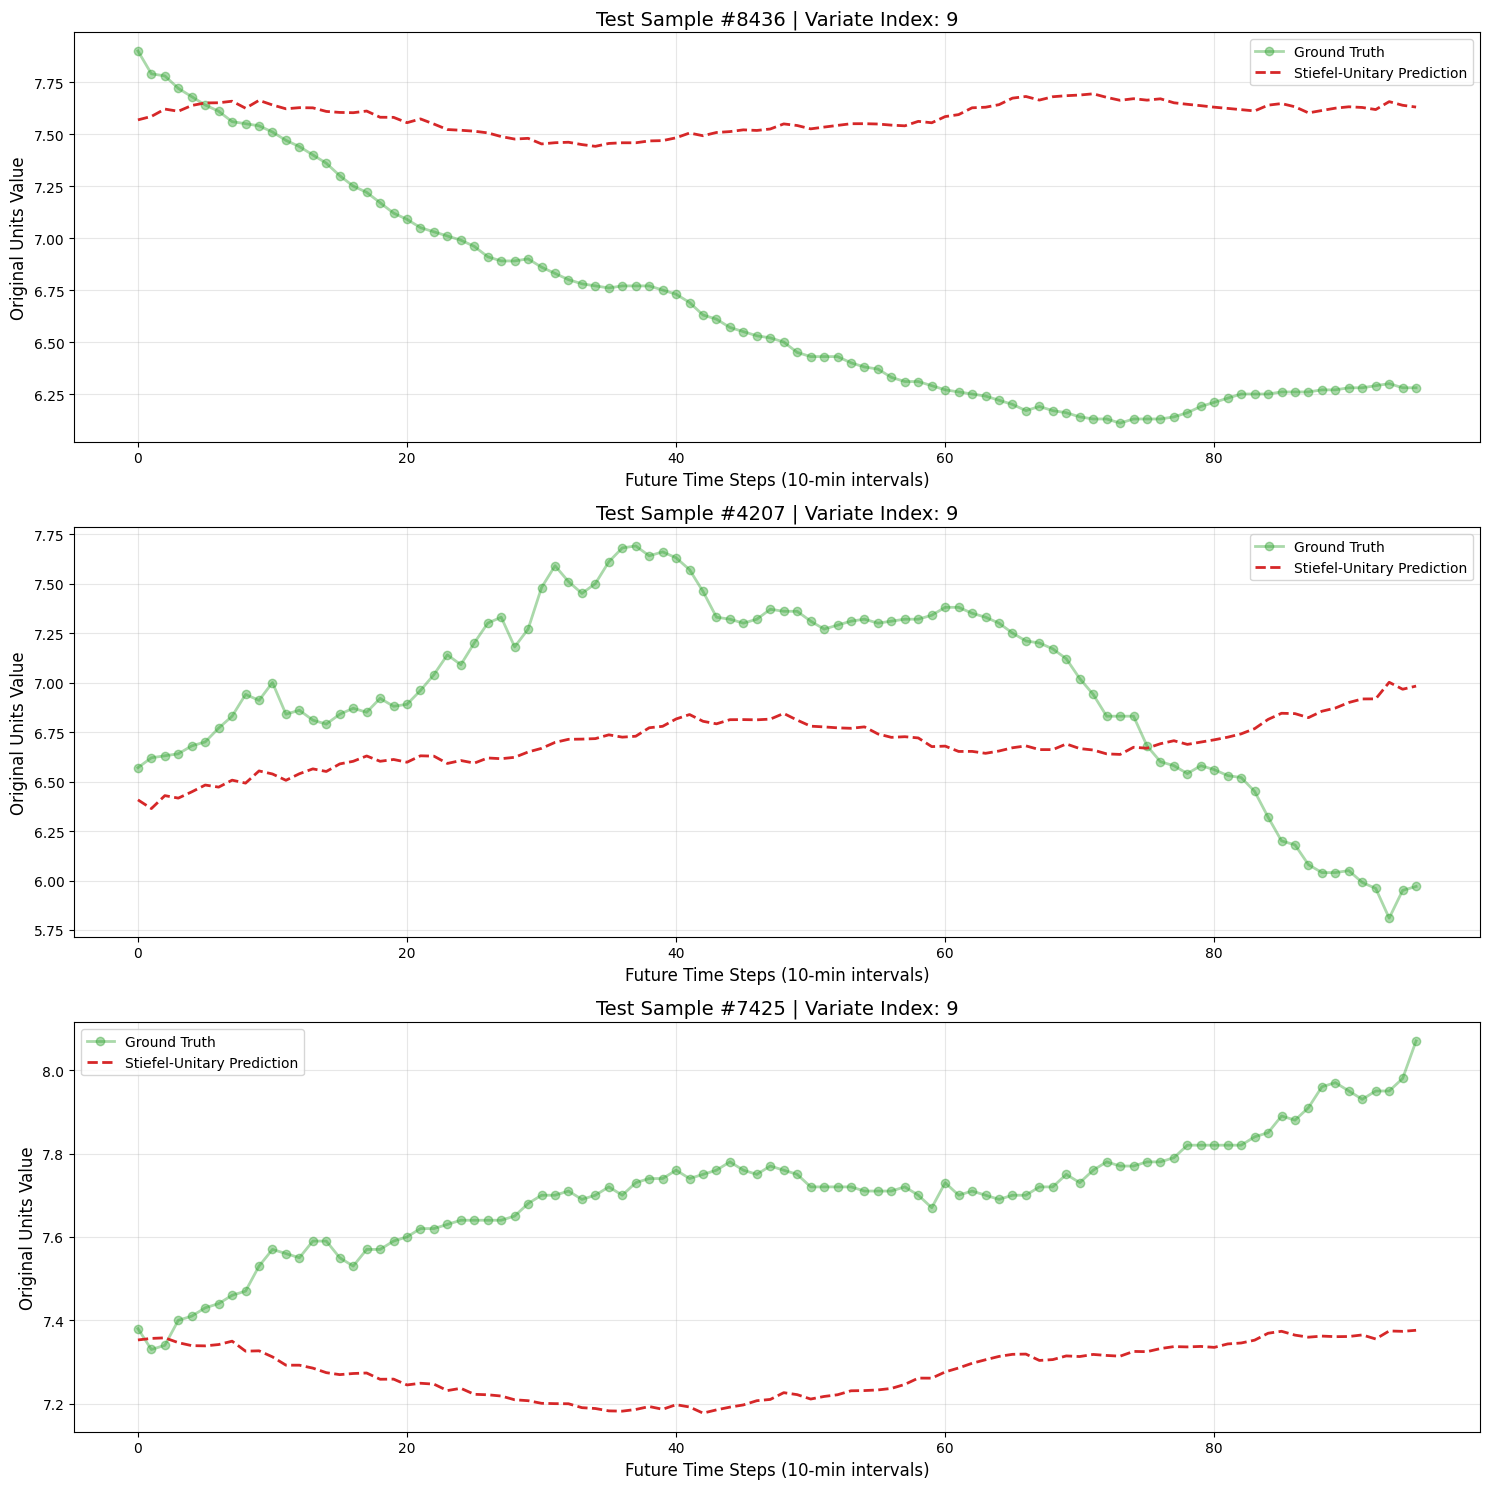

In [21]:
# Make sure the Stiefel_QuLTSF class is defined above this
loaded_model, loaded_scaler = load_kaggle_model(
    model_name="stiefel_v1_336_96", 
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

test_loader = DataLoader(TS_Dataset(test_raw, L, T), batch_size=32, shuffle=False)

# Run testing
# Variate index 1 is usually Temperature in the weather dataset
results = test_and_visualize(
    model=loaded_model, 
    dataloader=test_loader, 
    scaler=loaded_scaler, 
    configs={'L': L, 'T': T}, 
    device=device,
    plot_variate_idx=9, # Change this based on your dataset column
    num_plots=3
)

In [13]:
results

{'mse': np.float32(0.14727217), 'mae': np.float32(0.197916)}